# Import Libraries

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')



In [3]:
# !pip install pytest

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast, re
from sklearn import tree
from sklearn.metrics import ConfusionMatrixDisplay
from collections import Counter
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import joblib
import json


# Read Dataset & Overview

In [5]:
df = pd.read_csv("train_data.csv")


C:\Users\Sandra\AppData\Local\Temp\ipykernel_27004\933231161.py:1: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("train_data.csv")


In [6]:
print("Shape:", df.shape)

Shape: (1048575, 39)


In [7]:
print("\nColumns:", df.columns.tolist())


Columns: ['id', 'title', 'quality', 'theatrical', 'movie_valence', 'movie_vad_valence', 'movie_vad_arousal', 'movie_vad_dominance', 'movie_intensity_anger', 'movie_intensity_anticipation', 'movie_intensity_disgust', 'movie_intensity_fear', 'movie_intensity_joy', 'movie_intensity_sadness', 'movie_intensity_surprise', 'movie_intensity_trust', 'movie_scl_shift', 'movie_scl_coverage', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularityLevel', 'poster_path', 'tagline', 'genres', 'production_companies', 'production_countries', 'spoken_languages']


In [8]:
print("\nDtypes:\n", df.dtypes)


Dtypes:
 id                                int64
title                            object
quality                          object
theatrical                         bool
movie_valence                   float64
movie_vad_valence               float64
movie_vad_arousal               float64
movie_vad_dominance             float64
movie_intensity_anger           float64
movie_intensity_anticipation    float64
movie_intensity_disgust         float64
movie_intensity_fear            float64
movie_intensity_joy             float64
movie_intensity_sadness         float64
movie_intensity_surprise        float64
movie_intensity_trust           float64
movie_scl_shift                 float64
movie_scl_coverage              float64
vote_average                    float64
vote_count                        int64
status                           object
release_date                     object
revenue                           int64
runtime                           int64
adult                         

In [9]:
df.head()


,id,title,quality,theatrical,movie_valence,movie_vad_valence,movie_vad_arousal,movie_vad_dominance,movie_intensity_anger,movie_intensity_anticipation,...,original_language,original_title,overview,popularityLevel,poster_path,tagline,genres,production_companies,production_countries,spoken_languages
0,565770,Blue Beetle,real_confident,True,0.434939,0.445939,0.070364,0.405667,0.058714,0.077000,...,en,Blue Beetle,Recent college grad Jaime Reyes returns home f...,High,/mXLOHHc1Zeuwsl4xYKjKh2280oL.jpg,Jaime Reyes is a superhero whether he likes it...,"Action, Science Fiction, Adventure","Warner Bros. Pictures, The Safran Company, DC ...",United States of America,"English, Portuguese, Spanish"
1,980489,Gran Turismo,real_confident,True,0.508375,0.494900,0.231700,0.279400,0.000000,0.000000,...,en,Gran Turismo,The ultimate wish-fulfillment tale of a teenag...,High,/51tqzRtKMMZEYUpSYkrUE7v9ehm.jpg,From gamer to racer.,"Action, Drama, Adventure","PlayStation Productions, 2.0 Entertainment, Co...",United States of America,"English, German, Japanese"
2,968051,The Nun II,real_confident,True,-0.132556,-0.153909,0.115182,0.198364,0.319818,0.097273,...,en,The Nun II,"In 1956 France, a priest is violently murdered...",High,/c9kVD7W8CT5xe4O3hQ7bFWwk68U.jpg,Confess your sins.,"Horror, Mystery, Thriller","New Line Cinema, Atomic Monster, The Safran Co...",United States of America,"English, French"
3,615656,Meg 2: The Trench,real_confident,True,-0.003150,0.100458,0.067333,0.172458,0.000000,0.146500,...,en,Meg 2: The Trench,An exploratory dive into the deepest depths of...,High,/4m1Au3YkjqsxF8iwQy0fPYSxE0h.jpg,Back for seconds.,"Action, Science Fiction, Horror","Apelles Entertainment, Warner Bros. Pictures, ...","China, United States of America",English
4,762430,Retribution,real_confident,True,-0.300000,-0.318333,0.316333,0.096667,0.713667,0.000000,...,en,Retribution,When a mysterious caller puts a bomb under his...,High,/oUmmY7QWWn7OhKlcPOnirHJpP1F.jpg,All roads lead to the truth.,"Action, Mystery, Thriller, Crime","StudioCanal, The Picture Company, Ombra Films","France, United States of America","English, German"


# Pre Processing


### Null Handleing

In [10]:
def NullAnalysis(df):
    missing_values   = df.isnull().sum()
    missing_pct      = (df.isnull().mean() * 100).round(4)
    dtypes           = df.dtypes

    missing_info = pd.concat(
        [missing_values, missing_pct, dtypes],
        axis=1,
        keys=['Count', 'Percentage', 'DataType']
    ).sort_values(by='Percentage', ascending=False)

    print(missing_info)

In [11]:
NullAnalysis(df)

                               Count  Percentage DataType
homepage                      926145     88.3242   object
tagline                       899308     85.7648   object
movie_scl_shift               868689     82.8447  float64
movie_intensity_anger         868187     82.7968  float64
movie_intensity_disgust       868187     82.7968  float64
movie_intensity_joy           868187     82.7968  float64
movie_intensity_sadness       868187     82.7968  float64
movie_intensity_trust         868187     82.7968  float64
movie_intensity_fear          868187     82.7968  float64
movie_intensity_surprise      868187     82.7968  float64
movie_intensity_anticipation  868187     82.7968  float64
movie_valence                 795419     75.8571  float64
movie_vad_valence             791721     75.5045  float64
movie_vad_arousal             791721     75.5045  float64
movie_vad_dominance           791721     75.5045  float64
movie_scl_coverage            777899     74.1863  float64
backdrop_path 

In [12]:
null_cols = df.columns[df.isnull().any()].tolist()
null_cols

['title',
 'movie_valence',
 'movie_vad_valence',
 'movie_vad_arousal',
 'movie_vad_dominance',
 'movie_intensity_anger',
 'movie_intensity_anticipation',
 'movie_intensity_disgust',
 'movie_intensity_fear',
 'movie_intensity_joy',
 'movie_intensity_sadness',
 'movie_intensity_surprise',
 'movie_intensity_trust',
 'movie_scl_shift',
 'movie_scl_coverage',
 'release_date',
 'adult',
 'backdrop_path',
 'homepage',
 'imdb_id',
 'original_title',
 'overview',
 'poster_path',
 'tagline',
 'genres',
 'production_companies',
 'production_countries',
 'spoken_languages']

In [13]:
df = df.dropna(subset=['popularityLevel'])

In [14]:
cols_to_drop_early = ['backdrop_path', 'homepage', 'tagline', 'poster_path', 'id', 'imdb_id']
df = df.drop(columns=cols_to_drop_early)

In [15]:
print("Class distribution:\n", df['popularityLevel'].value_counts())

Class distribution:
 popularityLevel
Very Low    808170
Low         146963
Medium       77945
High         15497
Name: count, dtype: int64


### Encode Target & Train/Test Split

In [16]:
df['popularityLevel'] = df['popularityLevel'].astype(str).str.strip().str.lower()

In [17]:
le = LabelEncoder()
y = le.fit_transform(df['popularityLevel'])

In [18]:
X = df.drop(columns=['popularityLevel'])

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
y_train = pd.Series(y_train, index=X_train.index)
y_test  = pd.Series(y_test,  index=X_test.index)

In [21]:
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

Train size: (838860, 32) | Test size: (209715, 32)


### Drop High-Null Columns

In [22]:
high_null_cols = [col for col in X_train.columns if X_train[col].isnull().mean() > 0.7]
print("Dropping high-null columns:", high_null_cols)

Dropping high-null columns: ['movie_valence', 'movie_vad_valence', 'movie_vad_arousal', 'movie_vad_dominance', 'movie_intensity_anger', 'movie_intensity_anticipation', 'movie_intensity_disgust', 'movie_intensity_fear', 'movie_intensity_joy', 'movie_intensity_sadness', 'movie_intensity_surprise', 'movie_intensity_trust', 'movie_scl_shift', 'movie_scl_coverage']


In [23]:
X_train = X_train.drop(columns=high_null_cols)
X_test  = X_test.drop(columns=high_null_cols)

### Impute Remaining Nulls

In [24]:
#  Numerical
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
median_values = {}
for col in num_cols:
    median_val = X_train[col].median()
    median_values[col] = median_val
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col]  = X_test[col].fillna(median_val)

with open('median_values.json', 'w') as f:
    json.dump(median_values, f)

In [25]:
#  Multi-label columns
multi_label_cols = ['production_companies', 'production_countries', 'spoken_languages', 'genres']
for col in multi_label_cols:
    X_train[col] = X_train[col].fillna("[]")
    X_test[col]  = X_test[col].fillna("[]")

In [26]:
#  Overview
X_train['overview'] = X_train['overview'].fillna("")
X_test['overview']  = X_test['overview'].fillna("")

In [27]:
#  Adult
adult_map = {"False": 0, "True": 1, False: 0, True: 1, "Unknown": -1}
for dataset in [X_train, X_test]:
    dataset['adult'] = dataset['adult'].fillna("Unknown").map(adult_map).astype(int)

In [28]:
#  Bool columns
bool_cols = X_train.select_dtypes(include=['bool']).columns
for col in bool_cols:
    mode_val = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_val).astype(int)
    X_test[col]  = X_test[col].fillna(mode_val).astype(int)

In [29]:
print("Nulls remaining in train:", X_train.isnull().sum().sum())

Nulls remaining in train: 118535


### Title Feature Engineering & Drop Raw Title Columns

In [30]:
for dataset in [X_train, X_test]:
    title_text = dataset['title'].fillna("").astype(str)
    dataset['title_word_count']  = title_text.str.split().str.len()
    dataset['title_char_count']  = title_text.str.len()
    dataset['title_has_number']  = title_text.str.contains(r"\d", regex=True).astype(int)

In [31]:
X_train = X_train.drop(columns=['title', 'original_title'])
X_test  = X_test.drop(columns=['title', 'original_title'])

### Release Date Feature Engineering

In [32]:
for dataset in [X_train, X_test]:
    dataset['release_date'] = pd.to_datetime(dataset['release_date'], errors='coerce')

In [33]:
median_date = X_train['release_date'].median()
X_train['release_date'] = X_train['release_date'].fillna(median_date)
X_test['release_date']  = X_test['release_date'].fillna(median_date)

In [34]:
current_year = 2026
min_year = X_train['release_date'].dt.year.min()

In [35]:
for dataset in [X_train, X_test]:
    dataset['release_year']       = dataset['release_date'].dt.year
    dataset['release_month']      = dataset['release_date'].dt.month
    dataset['release_day']        = dataset['release_date'].dt.day
    dataset['release_dayofweek']  = dataset['release_date'].dt.dayofweek
    dataset['release_quarter']    = dataset['release_date'].dt.quarter
    dataset['movie_age']          = current_year - dataset['release_year']
    dataset['release_year_norm']  = dataset['release_year'] - min_year
    dataset['is_weekend_release'] = dataset['release_dayofweek'].isin([5, 6]).astype(int)
    dataset['is_summer']          = dataset['release_month'].isin([6, 7, 8]).astype(int)
    dataset['is_winter']          = dataset['release_month'].isin([12, 1, 2]).astype(int)
    dataset['is_holiday_season']  = dataset['release_month'].isin([11, 12]).astype(int)
    dataset['recency_score']      = 1 / (dataset['movie_age'] + 1)

In [36]:
X_train = X_train.drop(columns=['release_date'])
X_test  = X_test.drop(columns=['release_date'])

### Budget / Revenue Interaction Features

In [37]:
for dataset in [X_train, X_test]:
    dataset['budget_runtime_ratio'] = dataset['budget'] / (dataset['runtime'] + 1)
    dataset['budget_per_vote']      = dataset['budget'] / (dataset['vote_count'] + 1)
    dataset['revenue_per_vote']     = dataset['revenue'] / (dataset['vote_count'] + 1)

### Outlier Treatment (Log Transform)

In [38]:
log_cols = ['revenue', 'budget', 'vote_count', 'runtime',
            'budget_runtime_ratio', 'budget_per_vote', 'revenue_per_vote']

In [39]:
for col in log_cols:
    X_train[col] = np.log1p(X_train[col].clip(lower=0))
    X_test[col]  = np.log1p(X_test[col].clip(lower=0))

In [40]:
print("Skewness after log transform:\n",
      X_train[log_cols].skew().sort_values(ascending=False))

Skewness after log transform:
 revenue                 7.969300
revenue_per_vote        7.919335
budget_runtime_ratio    5.173310
budget                  4.908590
budget_per_vote         4.581004
vote_count              2.977561
runtime                -0.340883
dtype: float64


### Remove Duplicates

In [41]:
X_train = X_train.drop_duplicates()
X_test  = X_test.drop_duplicates()

In [42]:
y_train = y_train.loc[X_train.index]
y_test  = y_test.loc[X_test.index]

In [43]:
print("After dedup — Train:", X_train.shape, "| Test:", X_test.shape)
print("y_train size:", y_train.shape, "| y_test size:", y_test.shape)

After dedup — Train: (825756, 33) | Test: (207754, 33)
y_train size: (825756,) | y_test size: (207754,)


### Encode Categorical: original_language

In [44]:
def group_rare_categories(train_col, test_col, threshold=0.01):
    freq    = train_col.value_counts(normalize=True)
    common  = freq[freq >= threshold].index
    train_col = train_col.apply(lambda x: x if x in common else "other")
    test_col  = test_col.apply(lambda x: x if x in common else "other")
    return train_col, test_col

In [45]:
X_train['original_language'], X_test['original_language'] = group_rare_categories(
    X_train['original_language'], X_test['original_language'], threshold=0.01
)

C:\Users\Sandra\AppData\Local\Temp\ipykernel_27004\1653506882.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['original_language'], X_test['original_language'] = group_rare_categories(


In [46]:
ohe_lang = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
lang_train = ohe_lang.fit_transform(X_train[['original_language']])
lang_test  = ohe_lang.transform(X_test[['original_language']])
lang_cols  = ohe_lang.get_feature_names_out(['original_language'])

In [47]:
X_train = pd.concat([X_train.drop(columns=['original_language']),
                     pd.DataFrame(lang_train, columns=lang_cols, index=X_train.index)], axis=1)
X_test  = pd.concat([X_test.drop(columns=['original_language']),
                     pd.DataFrame(lang_test,  columns=lang_cols, index=X_test.index)], axis=1)

In [48]:
print(f"original_language expanded to {len(lang_cols)} columns")

original_language expanded to 11 columns


### Encode Categorical: quality & status

In [49]:
# Normalise text first
for dataset in [X_train, X_test]:
    dataset['quality'] = dataset['quality'].astype(str).str.strip().str.lower()
    dataset['status']  = dataset['status'].astype(str).str.strip().str.lower()

In [50]:
# Split quality into type + level
for dataset in [X_train, X_test]:
    split = dataset['quality'].str.split('_', expand=True)
    dataset['quality_type']  = split[0]
    dataset['quality_level'] = split[1]

In [51]:
quality_level_map = {'uncertain': 0, 'likely': 1, 'legitimate': 2, 'confident': 3}
X_train['quality_level'] = X_train['quality_level'].map(quality_level_map)
X_test['quality_level']  = X_test['quality_level'].map(quality_level_map)

In [52]:
# One-hot encode status and quality_type
ohe_cat = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe_cols = ['status', 'quality_type']

In [53]:
cat_train = ohe_cat.fit_transform(X_train[ohe_cols])
cat_test  = ohe_cat.transform(X_test[ohe_cols])
cat_feat_names = ohe_cat.get_feature_names_out(ohe_cols)

In [54]:
X_train = pd.concat([X_train.drop(columns=['quality', 'status', 'quality_type']),
                     pd.DataFrame(cat_train, columns=cat_feat_names, index=X_train.index)], axis=1)
X_test  = pd.concat([X_test.drop(columns=['quality', 'status', 'quality_type']),
                     pd.DataFrame(cat_test,  columns=cat_feat_names, index=X_test.index)], axis=1)

In [55]:
print(f"status + quality_type expanded to {len(cat_feat_names)} columns")

status + quality_type expanded to 9 columns


###  Encode Multi-label Columns (genres, production_countries, spoken_languages)

In [56]:
def parse_multilabel(series):
    def parse(x):
        if isinstance(x, list): return [str(i).strip().lower() for i in x]
        if pd.isna(x) or x in ['', 'unknown', '[]']: return []
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return [str(i).strip().lower() for i in parsed]
        except: pass
        return [i.strip().lower() for i in str(x).split(',')]
    return series.apply(parse)

In [57]:
def find_top_k(counter, target=0.9):
    total, cumulative = sum(counter.values()), 0
    for i, (_, count) in enumerate(counter.most_common()):
        cumulative += count
        if cumulative / total >= target:
            return i + 1

In [58]:
mlb_objects = {}
ml_cols = ['genres', 'production_countries', 'spoken_languages']

In [59]:
for col in ml_cols:
    X_train[col] = parse_multilabel(X_train[col])
    X_test[col]  = parse_multilabel(X_test[col])

    counter = Counter(label for sublist in X_train[col] for label in sublist)
    k       = find_top_k(counter, target=0.9)
    top_labels = set(label for label, _ in counter.most_common(k))

    X_train[col] = X_train[col].apply(lambda lst: [x for x in lst if x in top_labels] or ['other'])
    X_test[col]  = X_test[col].apply(lambda lst: [x for x in lst if x in top_labels] or ['other'])

    mlb = MultiLabelBinarizer()
    tr_enc = mlb.fit_transform(X_train[col])
    te_enc = mlb.transform(X_test[col])

    tr_df = pd.DataFrame(tr_enc, columns=[f"{col}_{c}" for c in mlb.classes_], index=X_train.index)
    te_df = pd.DataFrame(te_enc, columns=[f"{col}_{c}" for c in mlb.classes_], index=X_test.index)

    X_train = pd.concat([X_train.drop(columns=[col]), tr_df], axis=1)
    X_test  = pd.concat([X_test.drop(columns=[col]),  te_df], axis=1)

    mlb_objects[col] = mlb
    print(f"{col} → top-{k} labels kept, {tr_enc.shape[1]} columns created")

genres → top-13 labels kept, 14 columns created
production_countries → top-39 labels kept, 40 columns created
spoken_languages → top-26 labels kept, 27 columns created


### Encode High-Cardinality Column: production_companies

In [60]:
def parse_production_companies(series):
    def parse(x):
        if isinstance(x, list): return [str(i).strip().lower() for i in x]
        if pd.isna(x) or x in ['', 'unknown', '[]', '{}']: return []
        x = str(x).strip()
        if x.startswith('[') and x.endswith(']'):
            try:
                parsed = ast.literal_eval(x)
                if isinstance(parsed, list):
                    return [str(i).strip().lower() for i in parsed]
            except: pass
        matches = re.findall(r"'([^']*)'|\"([^\"]*)\"", x)
        extracted = [m[0] or m[1] for m in matches if m[0] or m[1]]
        if extracted: return [e.strip().lower() for e in extracted]
        return [i.strip().lower() for i in x.split(',') if i.strip()]
    return series.apply(parse)

In [61]:
X_train['production_companies'] = parse_production_companies(X_train['production_companies'])
X_test['production_companies']  = parse_production_companies(X_test['production_companies'])

In [62]:
# Build frequency map on train only
company_freq_map = {
    company: count / len(X_train)
    for company, count in Counter(
        company for sublist in X_train['production_companies'] for company in set(sublist)
    ).items()
}

In [63]:
def encode_company_frequency(series, freq_map):
    rows = []
    for companies in series:
        if not companies:
            rows.append([0, 0, 0, 0, 0])
            continue
        values = [freq_map.get(c, 0) for c in companies]
        rows.append([np.mean(values), np.max(values), np.min(values),
                     np.std(values), len(companies)])
    return pd.DataFrame(rows,
        columns=['production_companies_freq_mean', 'production_companies_freq_max',
                 'production_companies_freq_min', 'production_companies_freq_std',
                 'production_companies_count'],
        index=series.index)

X_train = pd.concat([X_train.drop(columns=['production_companies']),
                     encode_company_frequency(X_train['production_companies'], company_freq_map)], axis=1)
X_test  = pd.concat([X_test.drop(columns=['production_companies']),
                     encode_company_frequency(X_test['production_companies'], company_freq_map)], axis=1)


### Multi-label Count Features

In [64]:
for prefix in ['genres', 'production_countries', 'spoken_languages']:
    cols = [c for c in X_train.columns if c.startswith(f"{prefix}_")]
    X_train[f"num_{prefix}"] = X_train[cols].sum(axis=1)
    X_test[f"num_{prefix}"]  = X_test[cols].sum(axis=1)

In [65]:
X_train['num_companies'] = X_train['production_companies_count'] \
    if 'production_companies_count' in X_train.columns else 0


### Overview Text → LSA Topic Features

In [66]:
tfidf = TfidfVectorizer(max_features=500, stop_words='english', min_df=5)
X_overview_train = tfidf.fit_transform(X_train['overview'].fillna(''))
X_overview_test  = tfidf.transform(X_test['overview'].fillna(''))

In [67]:
svd = TruncatedSVD(n_components=20, random_state=42)
X_train_topics = svd.fit_transform(X_overview_train)
X_test_topics  = svd.transform(X_overview_test)

In [68]:
topic_cols = [f"overview_topic_{i}" for i in range(20)]
X_train = pd.concat([X_train.drop(columns=['overview']),
                     pd.DataFrame(X_train_topics, columns=topic_cols, index=X_train.index)], axis=1)
X_test  = pd.concat([X_test.drop(columns=['overview']),
                     pd.DataFrame(X_test_topics,  columns=topic_cols, index=X_test.index)], axis=1)

### Final Sanity Checks

In [69]:
# Replace any inf values that slipped through
X_train = X_train.replace([np.inf, -np.inf], 0)
X_test  = X_test.replace([np.inf, -np.inf], 0)

In [70]:
# Align columns (fills any test-only columns with 0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [71]:
# Check for leftover object columns
obj_cols = X_train.select_dtypes(include='object').columns.tolist()
if obj_cols:
    print("WARNING — object columns still present:", obj_cols)
else:
    print("All columns are numeric.")

All columns are numeric.


In [72]:
print(f"\nX_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")
print(f"Total nulls in train: {X_train.isnull().sum().sum()}")
print(f"Total nulls in test:  {X_test.isnull().sum().sum()}")


X_train: (825756, 156) | y_train: (825756,)
X_test:  (207754, 156)  | y_test:  (207754,)
Total nulls in train: 0
Total nulls in test:  0


# Feature Selection via Information Gain

In [73]:
def entropy(y):
    _, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return -np.sum([p * np.log2(p) for p in probs if p > 0])

In [74]:
def information_gain(X_col, y):
    parent_H = entropy(y)
    weighted_child_H = sum(
        (len(y[X_col == val]) / len(y)) * entropy(y[X_col == val])
        for val in X_col.unique()
    )
    return parent_H - weighted_child_H

In [75]:
def discretize(X_train, X_test, n_bins=10):
    X_tr, X_te = X_train.copy(), X_test.copy()
    for col in X_train.columns:
        if X_train[col].nunique() > n_bins:
            _, edges = pd.cut(X_train[col], bins=n_bins, retbins=True,
                              labels=False, duplicates='drop')
            X_tr[col] = pd.cut(X_train[col], bins=edges, labels=False,
                               duplicates='drop').fillna(0).astype(int)
            X_te[col] = pd.cut(X_test[col],  bins=edges, labels=False,
                               duplicates='drop').fillna(0).astype(int)
    return X_tr, X_te

In [76]:
X_train_disc, X_test_disc = discretize(X_train, X_test, n_bins=10)

In [77]:
y_train_arr = np.array(y_train)
ig_scores   = {col: information_gain(X_train_disc[col], y_train_arr)
               for col in X_train_disc.columns}

In [78]:
ig_series = pd.Series(ig_scores).sort_values(ascending=False)
selected_features = ig_series[ig_series > 0].index.tolist()

In [79]:
print(f"Features before selection: {X_train.shape[1]}")
print(f"Features after  selection: {len(selected_features)}")
print(f"\nTop 10 by Information Gain:\n{ig_series.head(10)}")

Features before selection: 156
Features after  selection: 156

Top 10 by Information Gain:
vote_count                    0.332622
quality_level                 0.248089
vote_average                  0.195594
quality_type_real             0.139813
quality_type_stub             0.130578
runtime                       0.113772
spoken_languages_other        0.077078
production_countries_other    0.069299
genres_other                  0.060036
spoken_languages_english      0.057636
dtype: float64


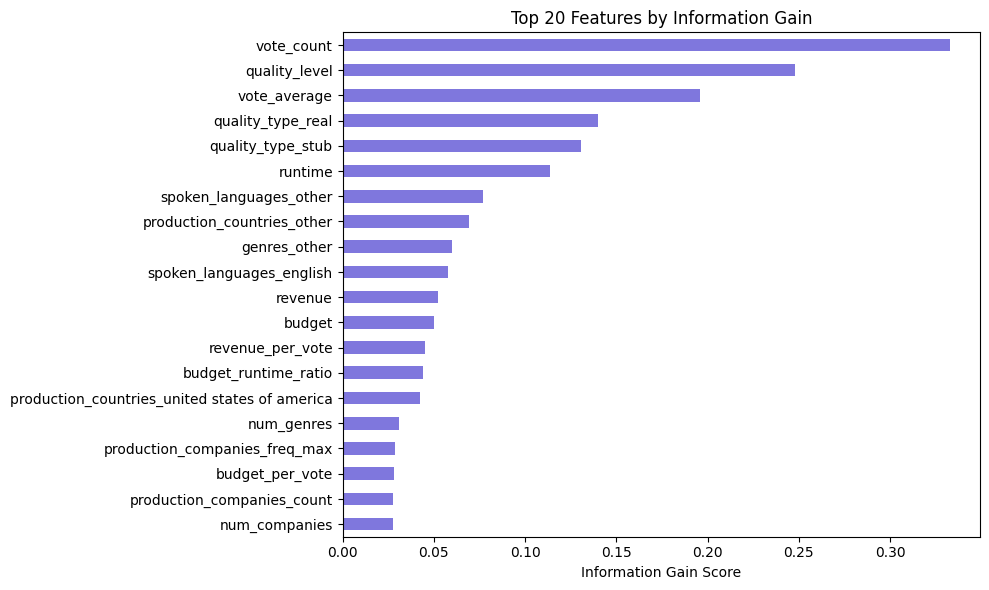

In [80]:
plt.figure(figsize=(10, 6))
ig_series.head(20).plot(kind='barh', color='#7F77DD')
plt.title('Top 20 Features by Information Gain')
plt.xlabel('Information Gain Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [81]:
X_train = X_train[selected_features]
X_test  = X_test[selected_features]

# Save

In [82]:
# joblib.dump(ohe_lang,           '/content/ohe_lang.pkl')
# joblib.dump(ohe_cat,            '/content/ohe_cat.pkl')
# joblib.dump(company_freq_map,   '/content/freq_map.pkl')
# joblib.dump(tfidf,              '/content/tfidf.pkl')
# joblib.dump(svd,                '/content/svd.pkl')
# joblib.dump(mlb_objects,        '/content/mlb_objects.pkl')
# joblib.dump(le,                 '/content/label_encoder.pkl')
# joblib.dump(selected_features,  '/content/selected_features.pkl')
# joblib.dump(X_train,            '/content/X_train_final.pkl')
# joblib.dump(X_test,             '/content/X_test_final.pkl')
# joblib.dump(y_train,            '/content/y_train.pkl')
# joblib.dump(y_test,             '/content/y_test.pkl')
# joblib.dump(le,                '/content/label_encoder.pkl')
# joblib.dump(selected_features, '/content/selected_features.pkl')
# joblib.dump(high_null_cols, '/content/high_null_cols.pkl')
# joblib.dump(median_values,  '/content/num_medians.pkl')
# common_languages = ohe_lang.categories_[0].tolist()
# joblib.dump(common_languages,   '/content/common_languages.pkl')
# # date params
# with open('date_params.json', 'w') as f:
#     json.dump(date_params, f)

# joblib.dump(ohe_lang,          '/content/drive/MyDrive/ohe_lang.pkl')
# joblib.dump(ohe_cat,           '/content/drive/MyDrive/ohe_cat.pkl')
# joblib.dump(company_freq_map,  '/content/drive/MyDrive/freq_map.pkl')
# joblib.dump(tfidf,             '/content/drive/MyDrive/tfidf.pkl')
# joblib.dump(svd,               '/content/drive/MyDrive/svd.pkl')
# joblib.dump(mlb_objects,       '/content/drive/MyDrive/mlb_objects.pkl')
# joblib.dump(le,                '/content/drive/MyDrive/label_encoder.pkl')
# joblib.dump(selected_features, '/content/drive/MyDrive/selected_features.pkl')
# joblib.dump(high_null_cols,    '/content/drive/MyDrive/high_null_cols.pkl')
# joblib.dump(median_values,     '/content/drive/MyDrive/num_medians.pkl')
# common_languages = ohe_lang.categories_[0].tolist()
# joblib.dump(common_languages,  '/content/drive/MyDrive/common_languages.pkl')

# date_params = {
#  'median_date': str(median_date),
#     'min_year': int(min_year)
#  }
# with open('/content/drive/MyDrive/date_params.json', 'w') as f:
#     json.dump(date_params, f)

In [83]:
print("All artifacts saved.")

All artifacts saved.


#Target Variable Exploration

popularityLevel
very low    808170
low         146963
medium       77945
high         15497
Name: count, dtype: int64


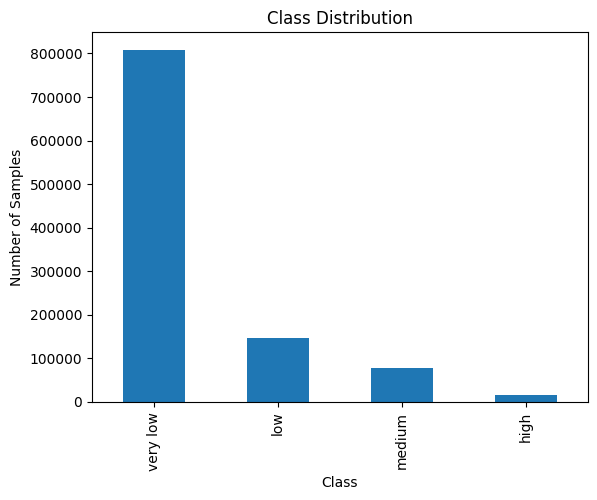

In [84]:
import pandas as pd
import matplotlib.pyplot as plt


class_counts =df['popularityLevel'].value_counts()
print(class_counts)


class_counts.plot(kind='bar', title='Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.show()

#Scalling


In [85]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#DecisionTreeClassifier

In [86]:
#from sklearn.model_selection import GridSearchCV
# param_grid = {
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [2, 5, 10],
#     'criterion': ['gini', 'entropy']
# }

# dt_model = DecisionTreeClassifier(random_state=42)


# grid_search = GridSearchCV(dt_model, param_grid, cv=5, scoring='accuracy')
# grid_search.fit(X_train_scaled, y_train)

# print("Best Parameters:", grid_search.best_params_)
# best_dt = grid_search.best_estimator_

Tuning max_depth

Depth       Train Acc   Test Acc    Time (s)
-------------------------------------------------------
5           0.83        0.83        17.47
10          0.85        0.84        31.39
20          0.89        0.82        56.76
30          0.92        0.80        69.44


C:\Users\Sandra\AppData\Local\Temp\ipykernel_27004\2838335184.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='label', y='accuracy', palette='Blues_d')
C:\Users\Sandra\AppData\Local\Temp\ipykernel_27004\2838335184.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='label', y='train_time', palette='Greens_d')
C:\Users\Sandra\AppData\Local\Temp\ipykernel_27004\2838335184.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='label', y='test_time', palette='Reds_d')


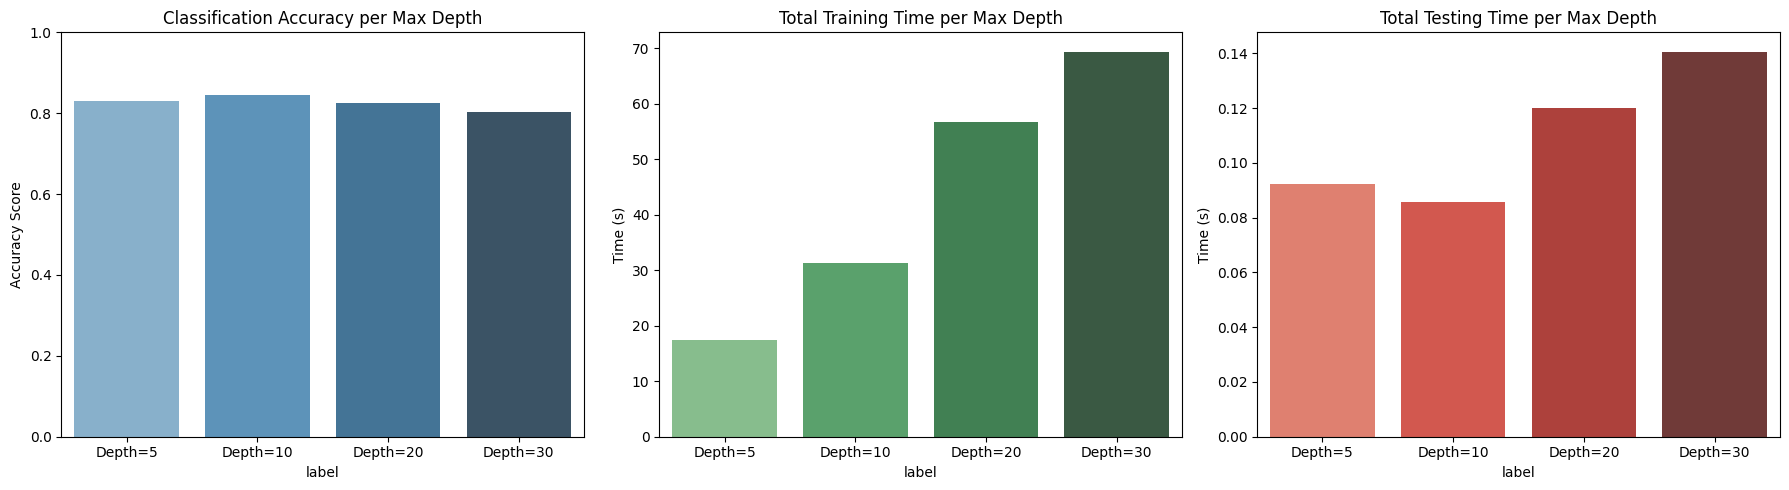


Best max_depth selected: 10


In [87]:
max_depth_values = [5, 10, 20, 30]
depth_results = []

print("Tuning max_depth\n")
print(f"{'Depth':<10}  {'Train Acc':<10}  {'Test Acc':<10}  {'Time (s)'}")
print("-" * 55)

for depth in max_depth_values:
    model = DecisionTreeClassifier(
        criterion='gini',
        max_depth=depth,
        min_samples_leaf=5,
        min_samples_split=2,
        random_state=42
    )


    start_train = time.time()
    model.fit(X_train_scaled, y_train)
    tr_time = time.time() - start_train

    start_test = time.time()
    y_test_pred = model.predict(X_test_scaled)
    ts_time = time.time() - start_test


    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, y_test_pred)


    depth_results.append({
        'max_depth': depth,
        'accuracy': test_acc,
        'train_acc': train_acc,
        'train_time': tr_time,
        'test_time': ts_time,
        'label': f"Depth={depth}"
    })

    print(f"{str(depth):<10}  {train_acc:<10.2f}  {test_acc:<10.2f}  {tr_time:.2f}")


results_df = pd.DataFrame(depth_results)


plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.barplot(data=results_df, x='label', y='accuracy', palette='Blues_d')
plt.title('Classification Accuracy per Max Depth')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1)

plt.subplot(1, 3, 2)
sns.barplot(data=results_df, x='label', y='train_time', palette='Greens_d')
plt.title('Total Training Time per Max Depth')
plt.ylabel('Time (s)')

plt.subplot(1, 3, 3)
sns.barplot(data=results_df, x='label', y='test_time', palette='Reds_d')
plt.title('Total Testing Time per Max Depth')
plt.ylabel('Time (s)')

plt.tight_layout()
plt.show()


best_depth = results_df.loc[results_df['accuracy'].idxmax(), 'max_depth']
print(f"\nBest max_depth selected: {best_depth}")



In [88]:
final_dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=best_depth,
    min_samples_leaf=5,
    min_samples_split=20,
    random_state=42
)


start_train = time.time()
final_dt_model .fit(X_train_scaled, y_train)
total_training_time = time.time() - start_train

y_pred_train=final_dt_model .predict(X_train_scaled)


start_test = time.time()
y_pred = final_dt_model .predict(X_test_scaled)
total_test_time = time.time() - start_test

final_acc_train = accuracy_score(y_train, y_pred_train)
final_acc_test = accuracy_score(y_test, y_pred)

print(f"Final Results:")
print(f"Best Parameters: Depth={best_depth}")
print(f"Final Train Accuracy: {final_acc_train:.2f}")
print(f"Final Test Accuracy: {final_acc_test:.2f}")
print(f"Total Training Time: {total_training_time:.4f} s")
print(f"Total Test Time: {total_test_time:.4f} s")


Final Results:
Best Parameters: Depth=10
Final Train Accuracy: 0.85
Final Test Accuracy: 0.84
Total Training Time: 37.2587 s
Total Test Time: 0.1118 s


In [89]:
from sklearn.metrics import classification_report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.68      0.75      3099
           1       0.52      0.31      0.39     29366
           2       0.74      0.64      0.69     15589
           3       0.88      0.96      0.92    159700

    accuracy                           0.84    207754
   macro avg       0.74      0.65      0.69    207754
weighted avg       0.82      0.84      0.83    207754



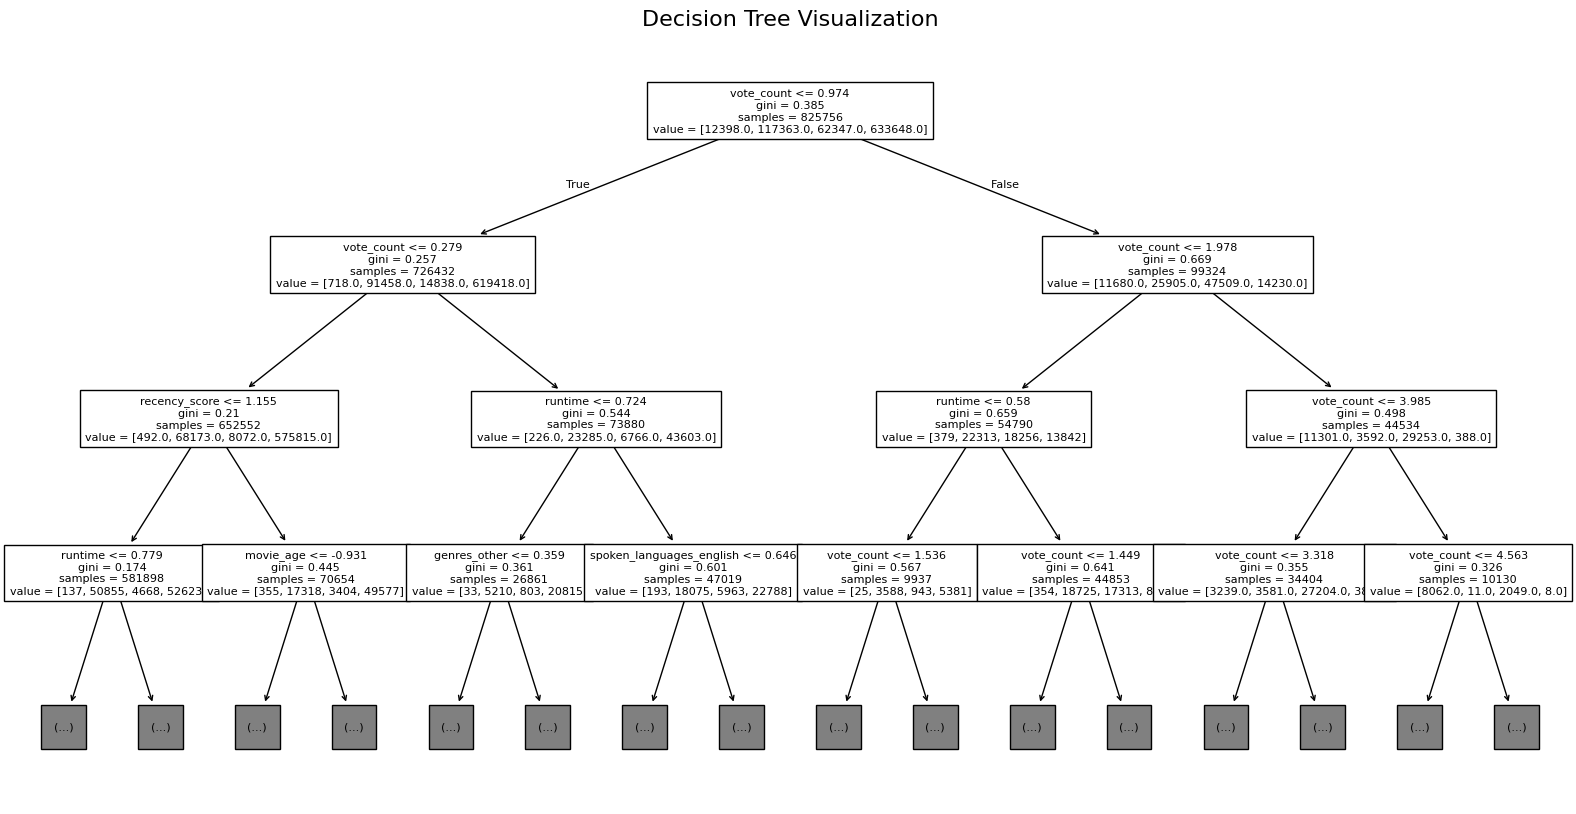

In [90]:
plt.figure(figsize=(20, 10))

tree.plot_tree(final_dt_model,
               max_depth=3,
               feature_names=list(X_train.columns),
               fontsize=8)

plt.title(f"Decision Tree Visualization", fontsize=16)
plt.show()

c:\Users\Sandra\pp\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


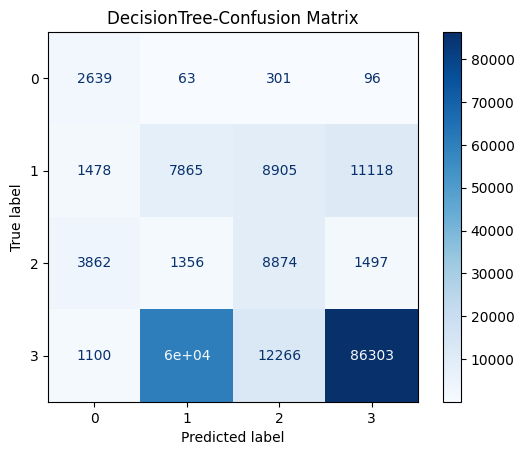

In [91]:
ConfusionMatrixDisplay.from_predictions(y_test, model.predict(X_test), cmap="Blues")
plt.title("DecisionTree-Confusion Matrix")
plt.show()

In [93]:
joblib.dump(final_dt_model, 'decisionTree_model.pkl')
print(f"Successfully saved model ")

Successfully saved model 


# XGBOOST

In [94]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

start_train = time.time()
xgb.fit(X_train_scaled, y_train)
total_training_time = time.time() - start_train

In [95]:
start_test = time.time()
y_pred_xgb = xgb.predict(X_test_scaled)
total_test_time = time.time() - start_test

y_pred_xgb_train = xgb.predict(X_train_scaled)
train_acc = accuracy_score(y_train, y_pred_xgb_train)
test_acc  = accuracy_score(y_test,  y_pred_xgb)

print(f"Final Results:")
print(f"Final Train Accuracy:  {train_acc:.2f}")
print(f"Final Test Accuracy:   {test_acc:.2f}")
print(f"Total Training Time:   {total_training_time:.4f} s")
print(f"Total Test Time:       {total_test_time:.4f} s")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


Final Results:
Final Train Accuracy:  0.85
Final Test Accuracy:   0.85
Total Training Time:   34.1426 s
Total Test Time:       0.4978 s

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.72      0.78      3099
           1       0.55      0.30      0.39     29366
           2       0.76      0.68      0.71     15589
           3       0.89      0.97      0.93    159700

    accuracy                           0.85    207754
   macro avg       0.76      0.67      0.70    207754
weighted avg       0.83      0.85      0.83    207754



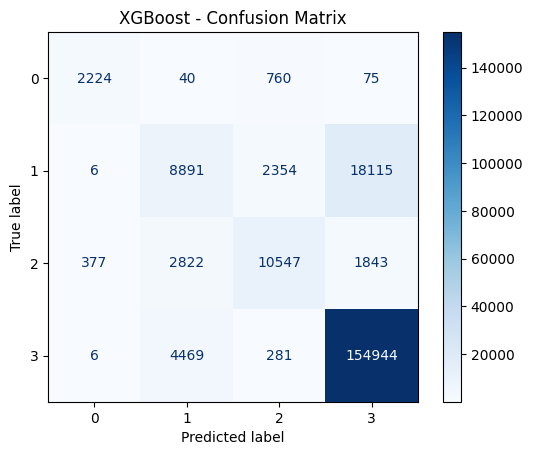

In [96]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, cmap="Blues")
plt.title("XGBoost - Confusion Matrix")
plt.show()

In [97]:
results_xgb = []

for n in [100, 200]:
    for depth in [4, 6, 8]:
        for lr in [0.05, 0.1]:

            xgb_grid_search = XGBClassifier(
                n_estimators=n,
                max_depth=depth,
                learning_rate=lr,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric='mlogloss',
                random_state=42,
                n_jobs=-1
            )

            xgb_grid_search.fit(X_train_scaled, y_train)
            y_pred = xgb_grid_search.predict(X_test_scaled)
            acc = accuracy_score(y_test, y_pred)
            results_xgb.append((n, depth, lr, acc))
            print(f"n={n}, depth={depth}, lr={lr}, acc={acc}")

n=100, depth=4, lr=0.05, acc=0.8413267614582631
n=100, depth=4, lr=0.1, acc=0.8459861181974836
n=100, depth=6, lr=0.05, acc=0.8474542006411429
n=100, depth=6, lr=0.1, acc=0.8500726821144238
n=100, depth=8, lr=0.05, acc=0.8510594260519653
n=100, depth=8, lr=0.1, acc=0.8523879203288505
n=200, depth=4, lr=0.05, acc=0.8461160795941354
n=200, depth=4, lr=0.1, acc=0.8488837760043128
n=200, depth=6, lr=0.05, acc=0.8500726821144238
n=200, depth=6, lr=0.1, acc=0.8518921416675491
n=200, depth=8, lr=0.05, acc=0.8525804557312976
n=200, depth=8, lr=0.1, acc=0.8529125793005189


In [98]:
import joblib
joblib.dump(xgb, 'xgboost_model.pkl')

['xgboost_model.pkl']

#AdaBoost with RandomForest

In [99]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score


adaboost_model = AdaBoostClassifier(
    estimator=RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        random_state=42
    ),
    n_estimators=50,
    random_state=42
)

start_train = time.time()
adaboost_model.fit(X_train_scaled, y_train)
tr_time = time.time() - start_train


start_test = time.time()
y_pred=adaboost_model.predict(X_test_scaled)
te_time=time.time()-start_test

adaboost_train_acc = accuracy_score(y_train, adaboost_model.predict(X_train_scaled))
adaboost_test_acc = accuracy_score(y_test,y_pred )

print(f"AdaBoost Training Accuracy: {adaboost_train_acc:.4f}")
print(f"AdaBoost Test Accuracy: {adaboost_test_acc:.4f}")
print(f"AdaBoost Training Time: {tr_time:.4f} seconds")
print(f"AdaBoost Test Time: {te_time:.4f} seconds")


AdaBoost Training Accuracy: 0.8487
AdaBoost Test Accuracy: 0.8111
AdaBoost Training Time: 9185.2528 seconds
AdaBoost Test Time: 47.6921 seconds


In [100]:
from sklearn.metrics import classification_report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.42      0.56      3099
           1       0.39      0.30      0.34     29366
           2       0.63      0.71      0.67     15589
           3       0.89      0.92      0.90    159700

    accuracy                           0.81    207754
   macro avg       0.69      0.59      0.62    207754
weighted avg       0.80      0.81      0.80    207754



In [102]:
import joblib
joblib.dump(adaboost_model, 'adaboost_model.pkl')

['adaboost_model.pkl']

# Logistic Regression

In [103]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import time


In [104]:

max_iterations = 1000
random_state = 42


C_values = [0.1, 1.0, 10.0]
solver_values = ['lbfgs', 'saga']

results = {
    'C': {'values': C_values, 'train_accuracy': [], 'test_accuracy': [], 'train_time': [], 'test_time': []},
    'solver': {'values': solver_values, 'train_accuracy': [], 'test_accuracy': [], 'train_time': [], 'test_time': []}
}

   

In [105]:
for C in C_values:
    model = LogisticRegression(
        C=C,
        solver='saga',
        max_iter=max_iterations,
        random_state=random_state,
        n_jobs=-1,
        tol=1e-3
    )

    start = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test_scaled)
    test_time = time.time() - start

    train_acc = model.score(X_train_scaled, y_train)
    test_acc  = accuracy_score(y_test, y_pred)

    results['C']['train_accuracy'].append(train_acc)
    results['C']['test_accuracy'].append(test_acc)
    results['C']['train_time'].append(train_time)
    results['C']['test_time'].append(test_time)

    print(f"C={C}, Train={train_acc:.4f}, Test={test_acc:.4f}, Time={train_time:.1f}s")

c:\Users\Sandra\pp\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


C=0.1, Train=0.8351, Test=0.8359, Time=170.7s


c:\Users\Sandra\pp\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


C=1.0, Train=0.8352, Test=0.8359, Time=188.6s


c:\Users\Sandra\pp\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


C=10.0, Train=0.8351, Test=0.8359, Time=190.8s


In [106]:
for solv in solver_values:
    model = LogisticRegression(
        C=1.0,
        solver=solv,
        max_iter=max_iterations,
        random_state=random_state,
        n_jobs=-1 if solv != 'liblinear' else 1,
        tol=1e-3
    )

    start = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test_scaled)
    test_time = time.time() - start

    train_acc = model.score(X_train_scaled, y_train)
    test_acc  = accuracy_score(y_test, y_pred)

    results['solver']['train_accuracy'].append(train_acc)
    results['solver']['test_accuracy'].append(test_acc)
    results['solver']['train_time'].append(train_time)
    results['solver']['test_time'].append(test_time)

    print(f"solver={solv}, Train={train_acc:.4f}, Test={test_acc:.4f}, Time={train_time:.1f}s")

c:\Users\Sandra\pp\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


solver=lbfgs, Train=0.8348, Test=0.8357, Time=8.2s


c:\Users\Sandra\pp\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


solver=saga, Train=0.8352, Test=0.8359, Time=190.3s


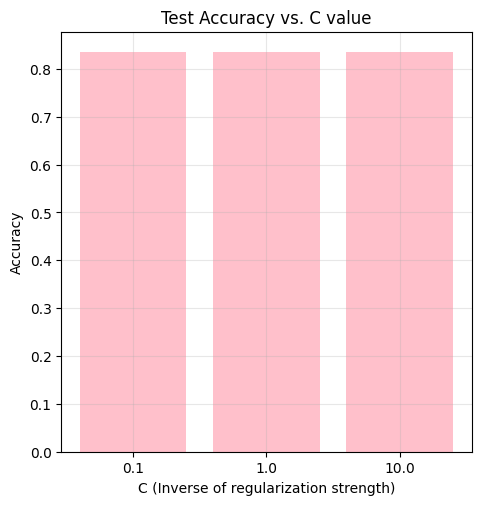

In [107]:

plt.figure(figsize=(18, 12))

# Plot for C values
# Accuracy
plt.subplot(2, 3, 1)
plt.bar([str(c) for c in C_values], results['C']['test_accuracy'], color='pink')
plt.title('Test Accuracy vs. C value')
plt.xlabel('C (Inverse of regularization strength)')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)



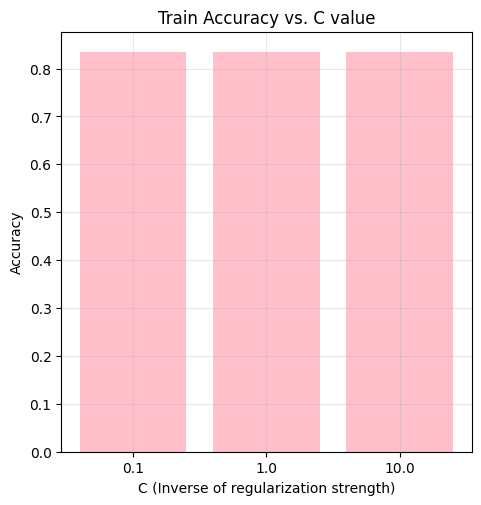

In [108]:
plt.figure(figsize=(18, 12))

# C values
# Accuracy
plt.subplot(2, 3, 1)
plt.bar([str(c) for c in C_values], results['C']['train_accuracy'], color='pink')
plt.title('Train Accuracy vs. C value')
plt.xlabel('C (Inverse of regularization strength)')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)

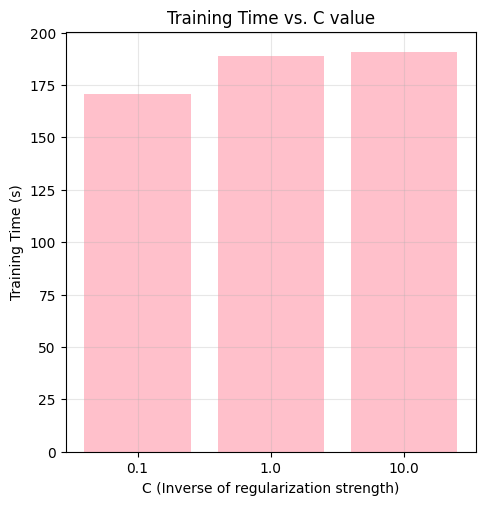

In [109]:
# Training time
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 2)
plt.bar([str(c) for c in C_values], results['C']['train_time'], color='pink')
plt.title('Training Time vs. C value')
plt.xlabel('C (Inverse of regularization strength)')
plt.ylabel('Training Time (s)')
plt.grid(True, alpha=0.3)


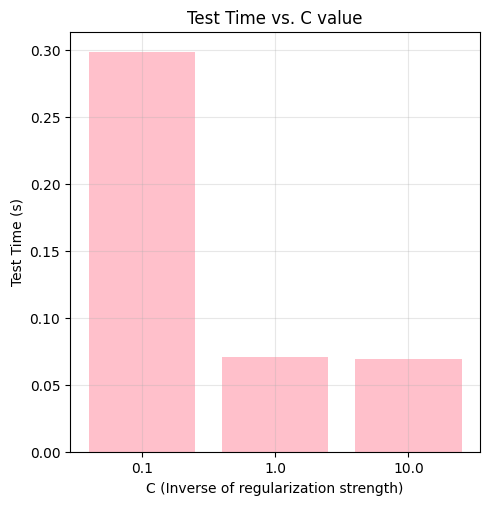

In [110]:
# Test time
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 3)
plt.bar([str(c) for c in C_values], results['C']['test_time'], color='pink')
plt.title('Test Time vs. C value')
plt.xlabel('C (Inverse of regularization strength)')
plt.ylabel('Test Time (s)')
plt.grid(True, alpha=0.3)

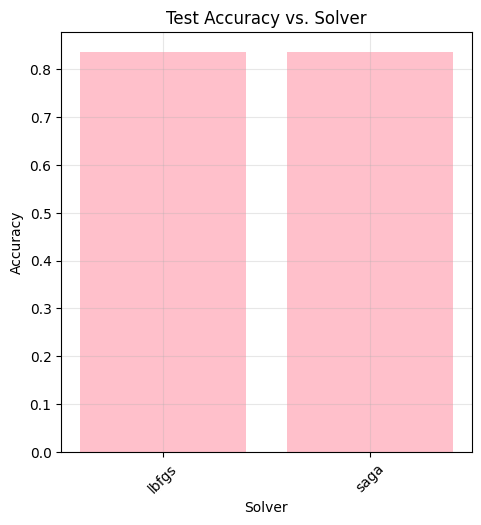

In [111]:
# solver values
plt.figure(figsize=(18, 12))

# Accuracy
plt.subplot(2, 3, 4)
plt.bar(solver_values, results['solver']['test_accuracy'], color='pink')
plt.title('Test Accuracy vs. Solver')
plt.xlabel('Solver')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

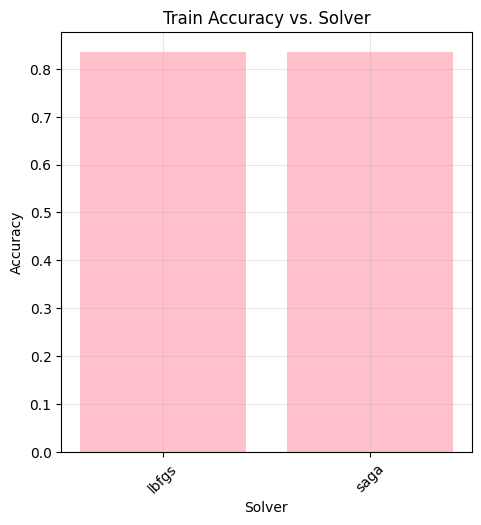

In [112]:
# Plot for solver values
plt.figure(figsize=(18, 12))

# Accuracy
plt.subplot(2, 3, 4)
plt.bar(solver_values, results['solver']['train_accuracy'], color='pink')
plt.title('Train Accuracy vs. Solver')
plt.xlabel('Solver')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

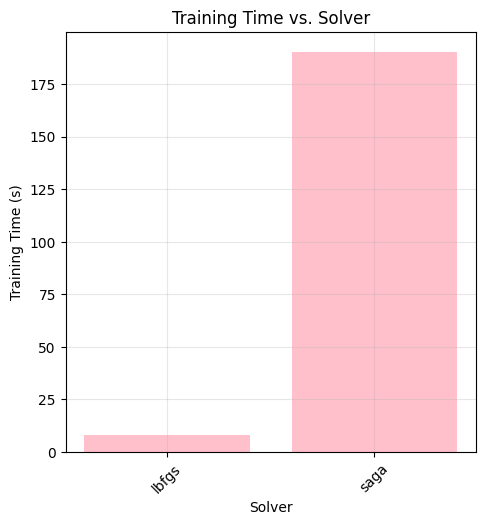

In [113]:
# Training time
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 5)
plt.bar(solver_values, results['solver']['train_time'], color='pink')
plt.title('Training Time vs. Solver')
plt.xlabel('Solver')
plt.ylabel('Training Time (s)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

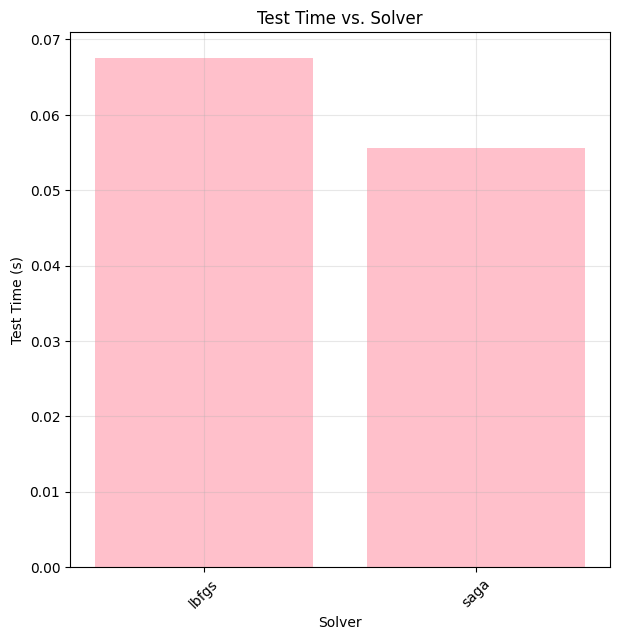

In [114]:
# Test time
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 6)
plt.bar(solver_values, results['solver']['test_time'], color='pink')
plt.title('Test Time vs. Solver')
plt.xlabel('Solver')
plt.ylabel('Test Time (s)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [115]:
best_c_accuracy_idx = np.argmax(results['C']['test_accuracy'])
best_c = C_values[best_c_accuracy_idx]
best_c_accuracy = results['C']['test_accuracy'][best_c_accuracy_idx]

best_solver_accuracy_idx = np.argmax(results['solver']['test_accuracy'])
best_solver = solver_values[best_solver_accuracy_idx]
best_solver_accuracy = results['solver']['test_accuracy'][best_solver_accuracy_idx]

print(f"Best C value: {best_c} with accuracy {best_c_accuracy:.4f}")
print(f"Best solver: {best_solver} with accuracy {best_solver_accuracy:.4f}")

Best C value: 1.0 with accuracy 0.8359
Best solver: saga with accuracy 0.8359


In [116]:
print("Testing the best combination")
best_model = LogisticRegression(C=best_c, solver=best_solver, max_iter=max_iterations, random_state=random_state)
best_model.fit(X_train_scaled, y_train)
best_pred = best_model.predict(X_test_scaled)
best_accuracy = accuracy_score(y_test, best_pred)
print(f"Best combination accuracy: {best_accuracy:.4f}")

Testing the best combination
Best combination accuracy: 0.8360


In [117]:
import joblib
joblib.dump(best_model, 'LogisticRegression_model.pkl')
print("saved")

saved


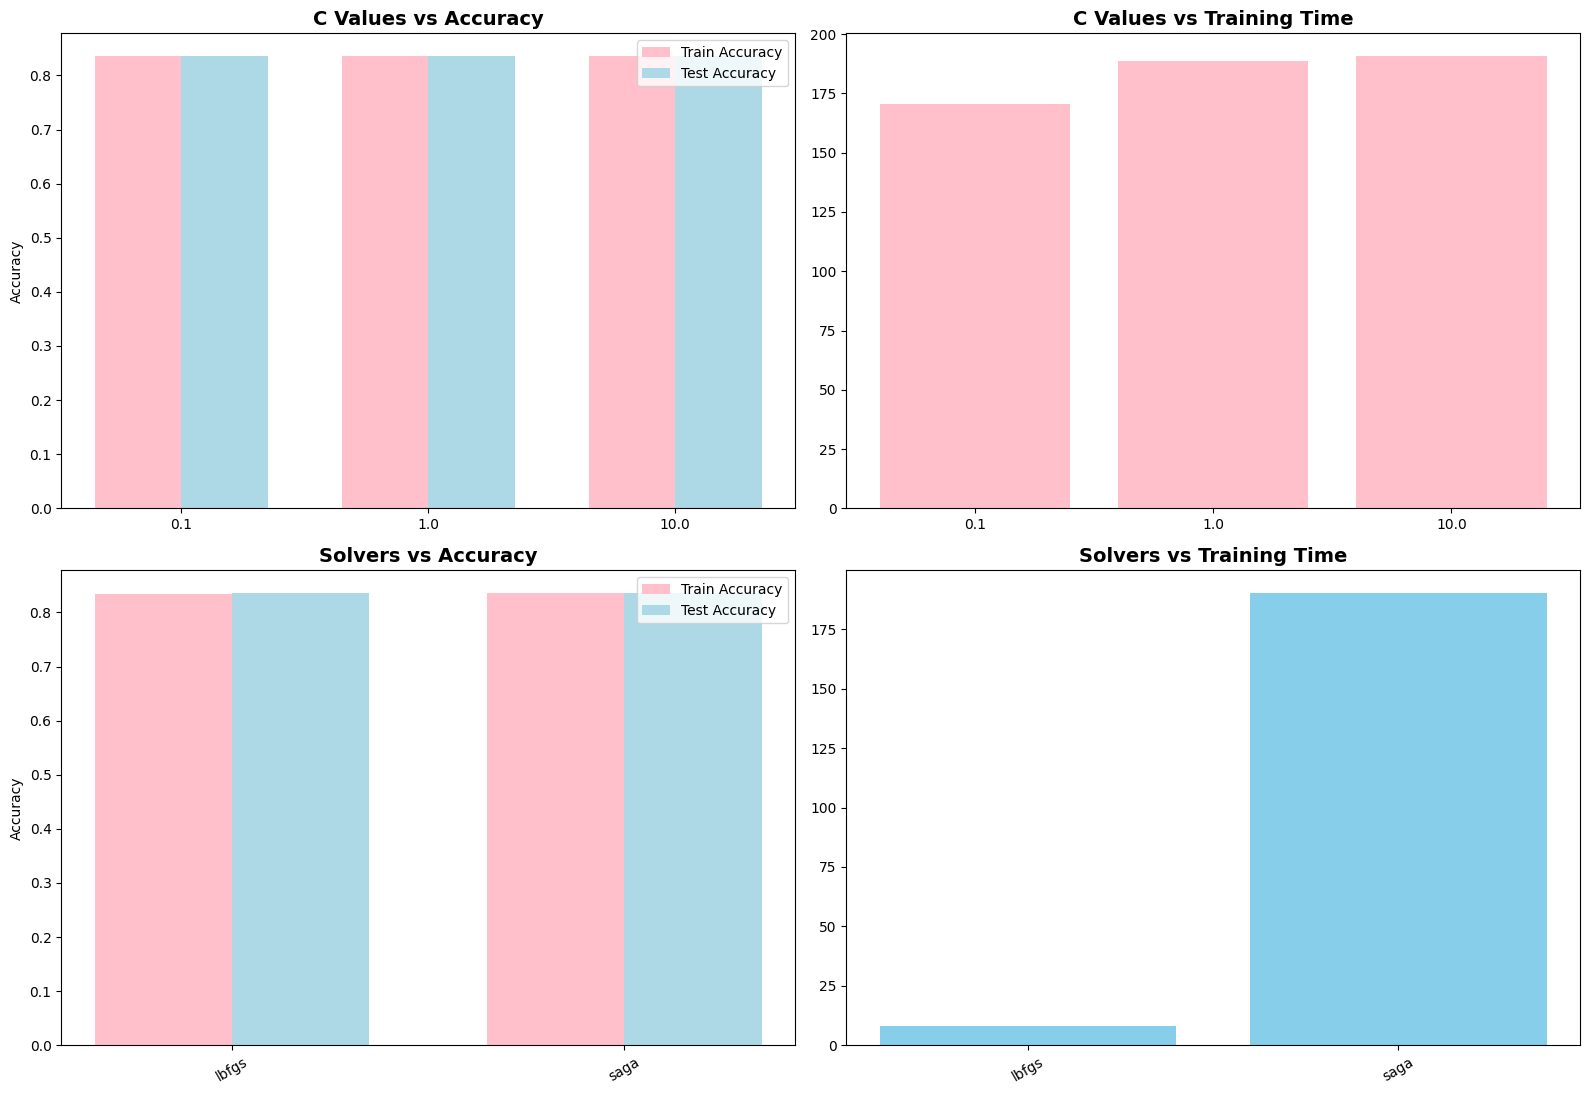

In [118]:
import matplotlib.pyplot as plt
import numpy as np


x_indexes_c = np.arange(len(C_values))
x_indexes_solver = np.arange(len(solver_values))
width = 0.35

plt.figure(figsize=(16, 12))


plt.subplot(2, 2, 1)

plt.bar(x_indexes_c - width/2, results['C']['train_accuracy'], width=width, color='pink', label='Train Accuracy')
plt.bar(x_indexes_c + width/2, results['C']['test_accuracy'], width=width, color='lightblue', label='Test Accuracy')

plt.title('C Values vs Accuracy', fontsize=14, fontweight='bold')
plt.xticks(ticks=x_indexes_c, labels=[str(c) for c in C_values])
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(2, 2, 2)
plt.bar([str(c) for c in C_values], results['C']['train_time'], color='pink')
plt.title('C Values vs Training Time', fontsize=14, fontweight='bold')

plt.subplot(2, 2, 3)
plt.bar(x_indexes_solver - width/2, results['solver']['train_accuracy'], width=width, color='pink', label='Train Accuracy')
plt.bar(x_indexes_solver + width/2, results['solver']['test_accuracy'], width=width, color='lightblue', label='Test Accuracy')

plt.title('Solvers vs Accuracy', fontsize=14, fontweight='bold')
plt.xticks(ticks=x_indexes_solver, labels=solver_values, rotation=30)
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(2, 2, 4)
plt.bar(solver_values, results['solver']['train_time'], color='skyblue')
plt.title('Solvers vs Training Time', fontsize=14, fontweight='bold')
plt.xticks(rotation=30)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [119]:
from sklearn.metrics import classification_report
print("Classification Report:")
print(classification_report(y_test, best_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.64      0.73      3099
           1       0.50      0.18      0.26     29366
           2       0.72      0.65      0.68     15589
           3       0.87      0.98      0.92    159700

    accuracy                           0.84    207754
   macro avg       0.73      0.61      0.65    207754
weighted avg       0.80      0.84      0.81    207754



In [120]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

##